In [1]:
%cd ..

/home/eli/AnacondaProjects/wgvp_pc


In [2]:
import hydra
import math
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import numpyro
from omegaconf import OmegaConf
import rootutils
import sys
import warnings

In [3]:
from src import test, train
import src.experiment as experiment

In [4]:
warnings.filterwarnings("ignore")

In [5]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-03-20_00-21-01/saved/checkpoint-epoch2000.npy",
                                                            "+experiment=nnpvae_fpi", "trainer._target_=src.trainer.PVaeTrainer",
                                                            "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [6]:
metrics

{'loss': np.float32(-39408.574),
 'loss_batch_mean': np.float32(-307.8795),
 'log_w': np.float32(34482.5),
 'log_w_batch_mean': np.float32(269.39453)}

In [7]:
for data, _, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    break

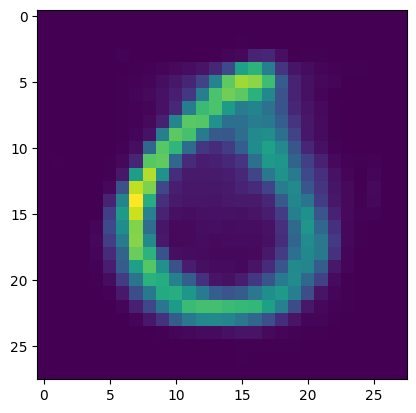

In [8]:
plt.imshow(recons[0].squeeze())

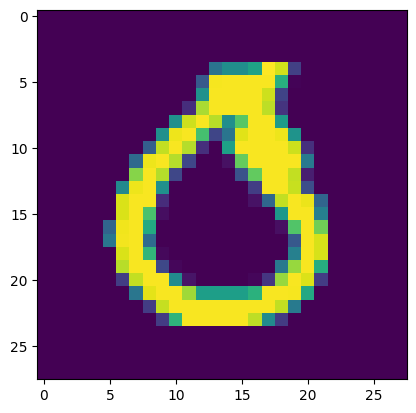

In [9]:
plt.imshow(data[0].squeeze())

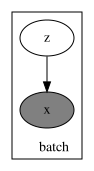

In [10]:
objects['monad'].render_model()

78it [00:10,  7.76it/s]


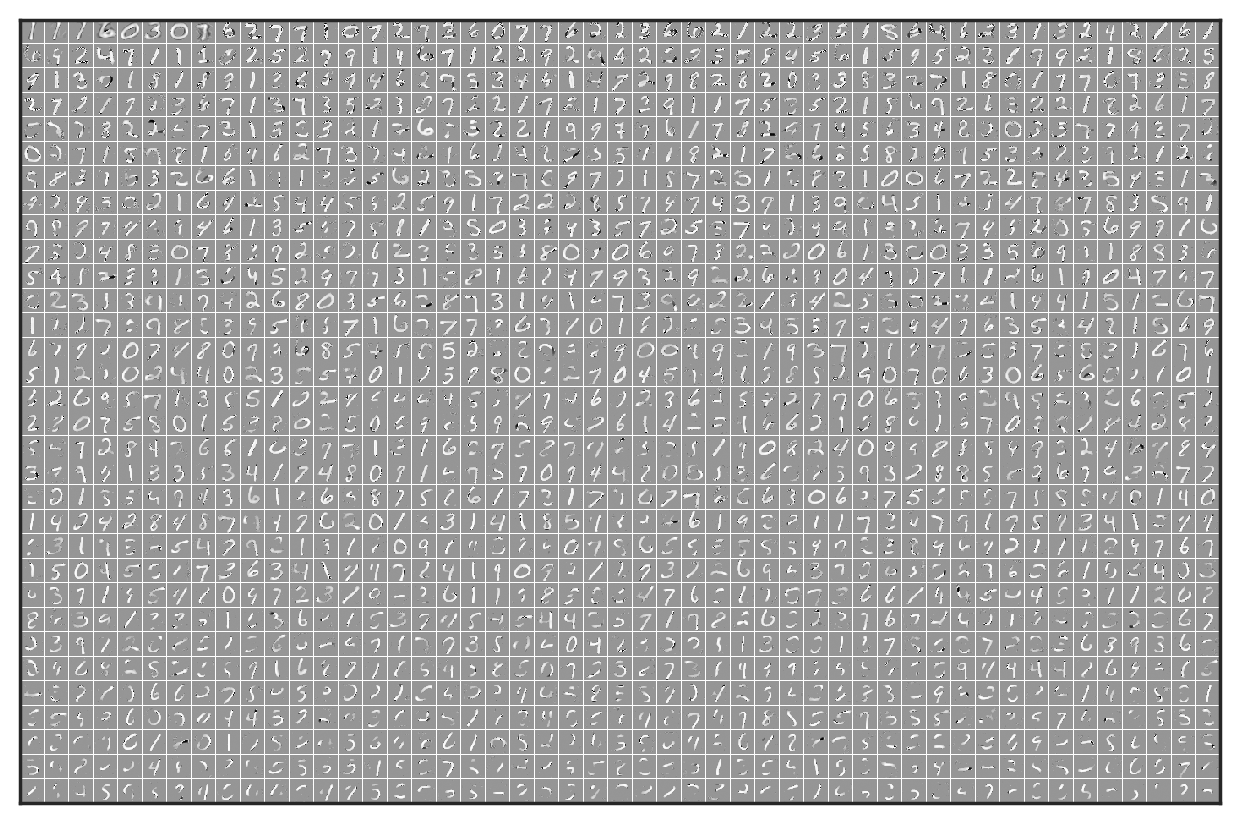

(<Figure size 1600x800 with 1 Axes>, <Axes: >)

In [11]:
u_final = objects["trainer"].proposal_us(objects["datamodule"], objects["monad"], max_steps=100)
u_order = np.argsort(u_final)
experiment.pvae_convergence.show_decoder(objects["datamodule"], objects["monad"].parameters, method="abs-max", order=u_order)

In [12]:
def r2(xs, xs_hat):
    squared_errors = ((xs - xs_hat) ** 2).sum()
    total_squares = ((xs - xs.mean(axis=0, keepdims=True)) ** 2).sum()
    return 1.0 - squared_errors / (total_squares + jnp.finfo("float64").eps)

def portion_zeros(zs):
    return (zs == 0).mean()

In [13]:
xs, xs_hat, zs = [], [], []

for data, _, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

In [14]:
portion_zeros(zs)

Array(0.9823935, dtype=float32)

In [15]:
r2(xs, xs_hat)

Array(0.78229535, dtype=float32)

In [16]:
xs.shape

(9984, 1, 28, 28)

In [17]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                                            "+experiment=pvae_fpi", "data=omniglot", "trainer._target_=src.trainer.PVaeTrainer",
                                                            "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [18]:
metrics

{'loss': np.float32(-28105.564),
 'loss_batch_mean': np.float32(-219.57472),
 'log_w': np.float32(24592.367),
 'log_w_batch_mean': np.float32(192.12787)}

In [19]:
for data, _, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    break

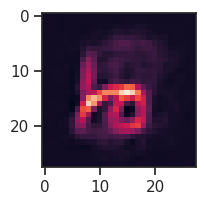

In [20]:
plt.imshow(recons[0].squeeze())

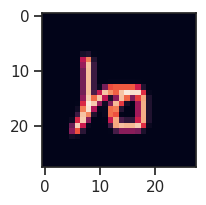

In [21]:
plt.imshow(data[0].squeeze())

102it [00:14,  6.95it/s]


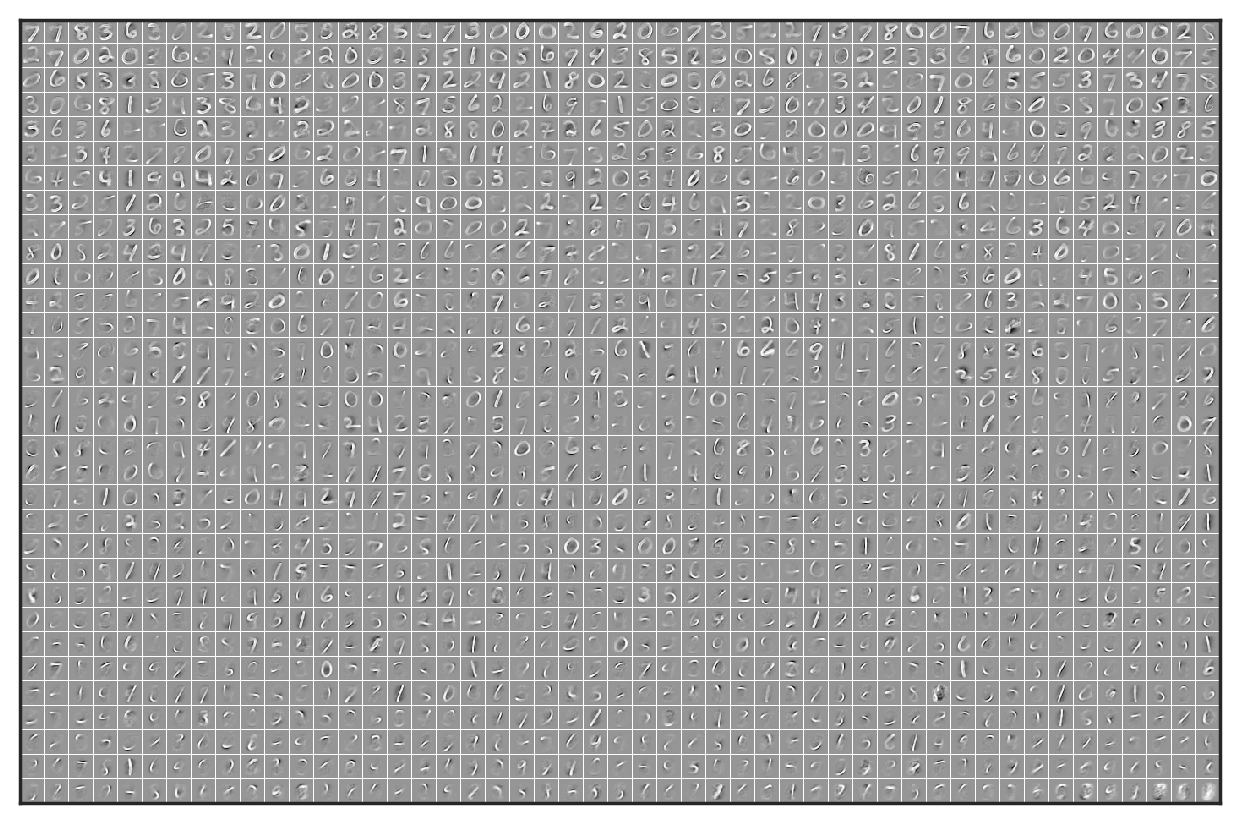

(<Figure size 1600x800 with 1 Axes>, <Axes: >)

In [22]:
u_final = objects["trainer"].proposal_us(objects["datamodule"], objects["monad"], max_steps=100)
u_order = np.argsort(u_final)
experiment.pvae_convergence.show_decoder(objects["datamodule"], objects["monad"].parameters, method="abs-max", order=u_order)

In [23]:
xs, xs_hat, zs = [], [], []

for data, _, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

In [24]:
portion_zeros(zs)

Array(0.93021446, dtype=float32)

In [25]:
r2(xs, xs_hat)

Array(0.6238761, dtype=float32)

In [26]:
xs.shape

(13056, 1, 28, 28)

In [27]:
metrics = objects["trainer"].analysis(objects["datamodule"], objects["monad"], t_total=100)

15it [07:47, 31.13s/it]


In [28]:
metrics

{'du_norm': Array([168.18881 , 152.77515 , 120.844124, 108.8089  , 110.0539  ,
        112.450386, 111.58864 , 109.860916, 110.008575, 110.4797  ,
        110.33237 , 109.98068 , 109.86643 , 109.90736 , 109.85035 ,
        109.75634 , 109.76607 , 109.78655 , 109.74244 , 109.72376 ,
        109.69956 , 109.68124 , 109.652214, 109.652245, 109.679756,
        109.6767  , 109.71249 , 109.66128 , 109.66688 , 109.638466,
        109.642426, 109.629   , 109.67733 , 109.65465 , 109.67332 ,
        109.666466, 109.62766 , 109.650475, 109.677666, 109.67556 ,
        109.66252 , 109.65378 , 109.65308 , 109.64413 , 109.66481 ,
        109.67451 , 109.69456 , 109.675835, 109.678154, 109.67175 ,
        109.67091 , 109.653015, 109.664314, 109.66866 , 109.66696 ,
        109.699104, 109.69508 , 109.68851 , 109.683426, 109.65281 ,
        109.68021 , 109.70776 , 109.70236 , 109.69349 , 109.68209 ,
        109.66643 , 109.70879 , 109.680016, 109.69291 , 109.675064,
        109.700005, 109.68084 , 109.6

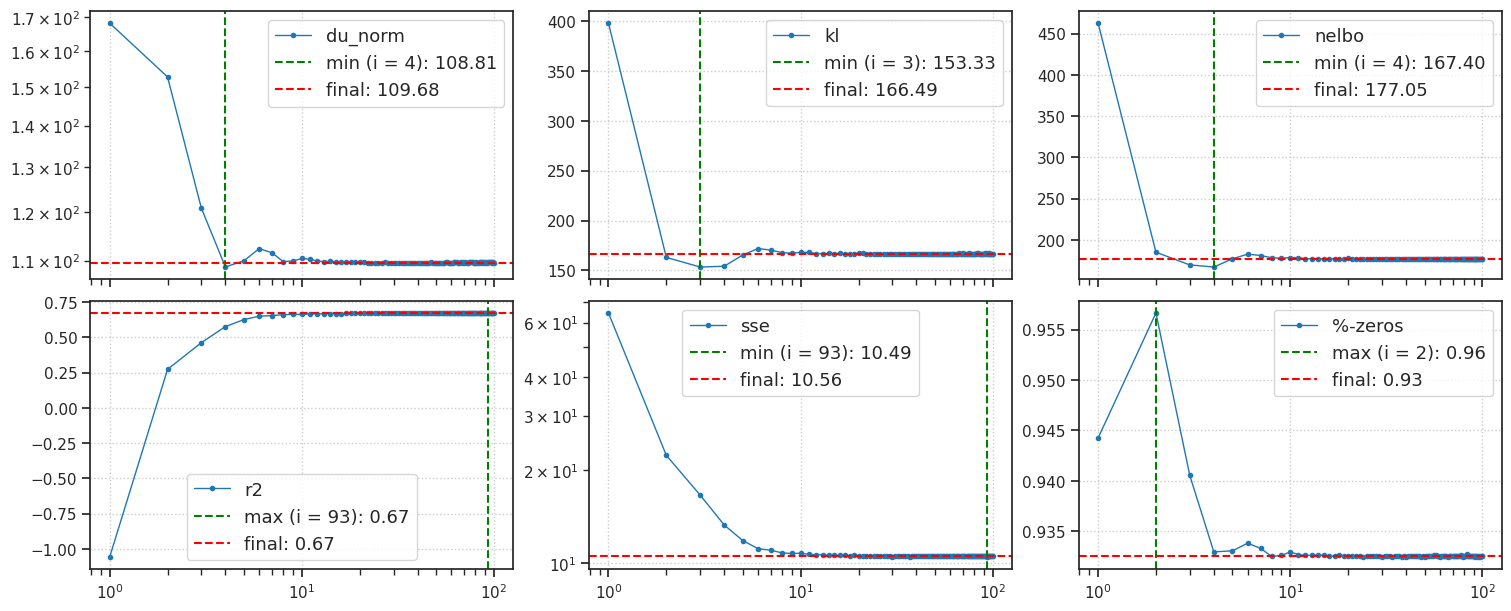

(<Figure size 1500x600 with 6 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >]], dtype=object))

In [29]:
experiment.plot_convergence(metrics)

In [30]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                                            "+experiment=pvae_fpi", "data=emnist", "trainer._target_=src.trainer.PVaeTrainer",
                                                            "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [31]:
metrics

{'loss': np.float32(142398.95),
 'loss_batch_mean': np.float32(1112.4918),
 'log_w': np.float32(-124599.07),
 'log_w_batch_mean': np.float32(-973.43024)}

In [32]:
for data, _, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    break

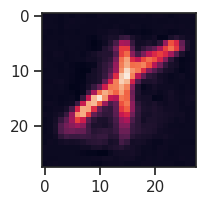

In [33]:
plt.imshow(recons[0].squeeze())

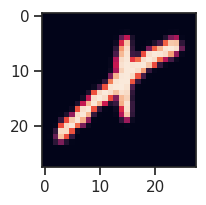

In [34]:
plt.imshow(data[0].squeeze())

146it [00:22,  6.35it/s]


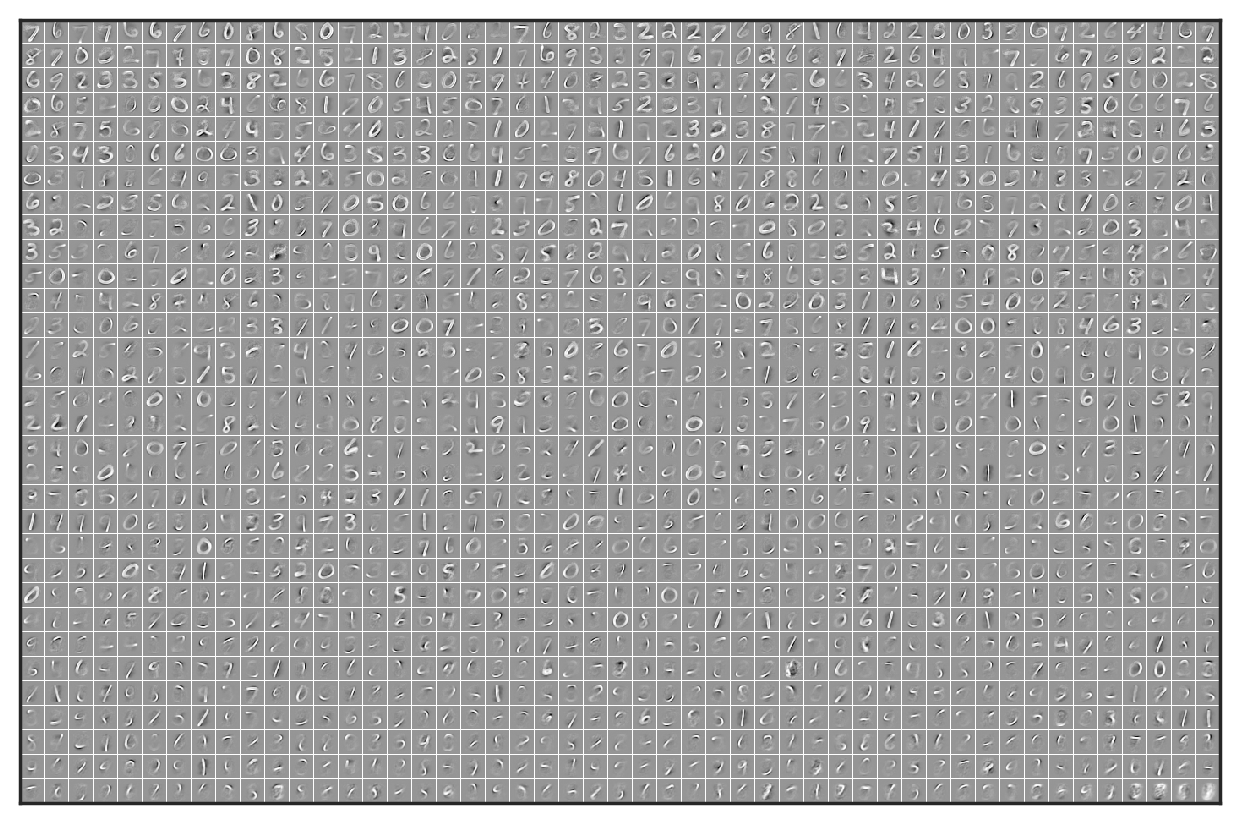

(<Figure size 1600x800 with 1 Axes>, <Axes: >)

In [35]:
u_final = objects["trainer"].proposal_us(objects["datamodule"], objects["monad"], max_steps=100)
u_order = np.argsort(u_final)
experiment.pvae_convergence.show_decoder(objects["datamodule"], objects["monad"].parameters, method="abs-max", order=u_order)

In [36]:
xs, xs_hat, zs = [], [], []

for data, _, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

In [37]:
portion_zeros(zs)

Array(0.91501176, dtype=float32)

In [38]:
r2(xs, xs_hat)

Array(0.5268894, dtype=float32)

In [39]:
xs.shape

(18688, 1, 28, 28)

In [40]:
metrics = objects["trainer"].analysis(objects["datamodule"], objects["monad"], t_total=100)

88it [49:41, 33.88s/it]


In [41]:
metrics

{'du_norm': Array([165.88379 , 140.78519 , 114.183205, 106.27266 , 108.54194 ,
        110.30348 , 108.980125, 108.09287 , 108.33309 , 108.511086,
        108.40391 , 108.22914 , 108.13885 , 108.16654 , 108.17308 ,
        108.1147  , 108.07042 , 108.07142 , 108.0771  , 108.05475 ,
        108.039246, 108.04208 , 108.03988 , 108.020454, 108.01958 ,
        108.00834 , 108.01209 , 108.024994, 108.02108 , 108.021545,
        108.010086, 108.006935, 108.01512 , 108.02321 , 108.01652 ,
        108.02266 , 108.01877 , 108.00956 , 108.014534, 108.012596,
        108.02132 , 108.02086 , 108.016884, 108.017204, 108.01939 ,
        108.02103 , 108.02053 , 108.02783 , 108.02627 , 108.021706,
        108.02676 , 108.017334, 108.02271 , 108.02583 , 108.02855 ,
        108.02998 , 108.03048 , 108.03168 , 108.03672 , 108.02515 ,
        108.0267  , 108.04089 , 108.031555, 108.036575, 108.03631 ,
        108.037285, 108.036095, 108.02647 , 108.0334  , 108.037285,
        108.04197 , 108.036644, 108.0

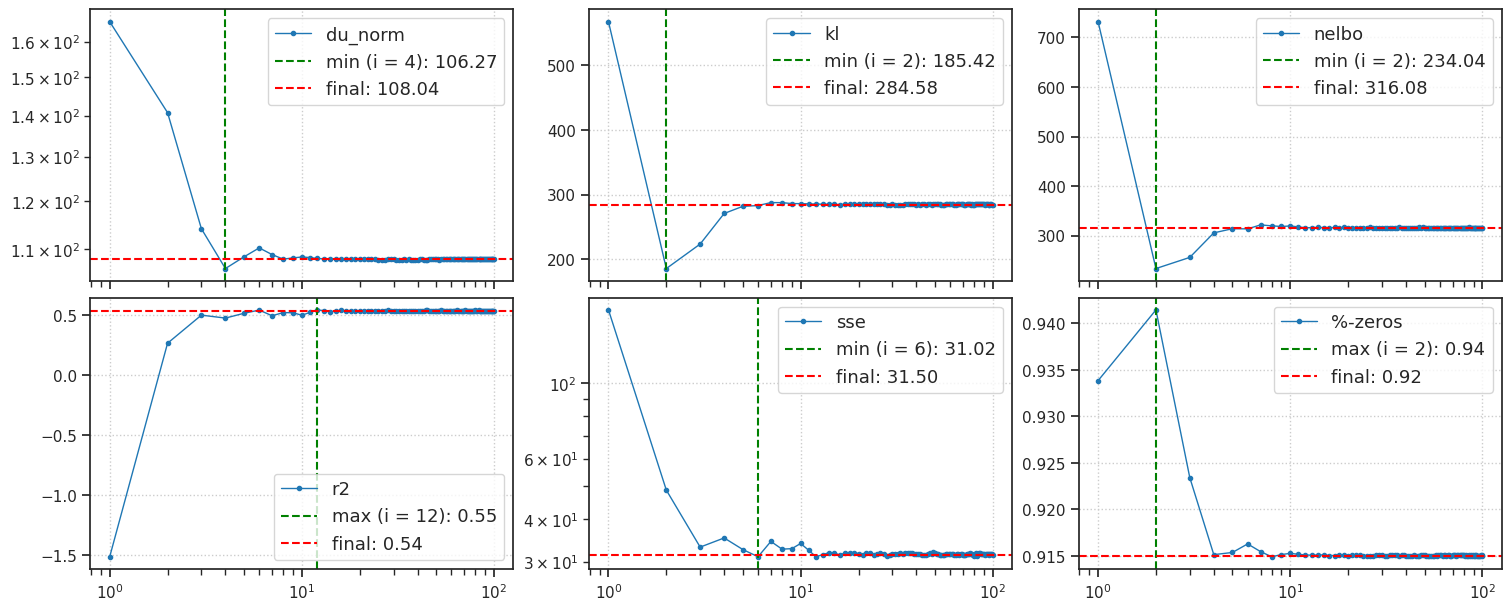

(<Figure size 1500x600 with 6 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >]], dtype=object))

In [42]:
experiment.plot_convergence(metrics)